In [33]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import wandb
import xarray as xr
from context_flux_no.training.io import load_model
from jaxtyping import Array, Float
from matplotlib.animation import ArtistAnimation


datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

# jax.config.update("jax_default_device", jax.devices("gpu")[2])

## Query wandb API and obtain loss curves

In [169]:
api = wandb.Api()
run_dpot = api.run("jhko725/hyperfluxfno/cgwa58nd")
run_hyperfluxfno = api.run("jhko725/hyperfluxfno/nni87so3")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.


<IPython.core.display.Javascript object>

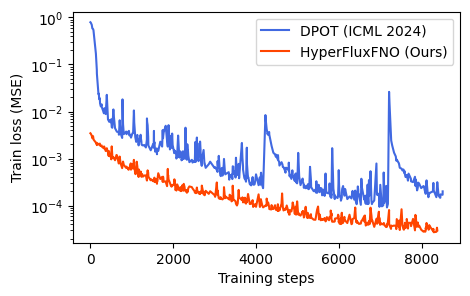

In [184]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(
    *run_dpot.history(keys=["train_loss"]).to_numpy().T,
    label="DPOT (ICML 2024)",
    color="royalblue",
)
ax.plot(
    *run_hyperfluxfno.history(keys=["train_loss"]).to_numpy().T,
    label="HyperFluxFNO (Ours)",
    color="orangered",
)
ax.set_yscale("log", base=10)
ax.set_ylabel("Train loss (MSE)")
ax.set_xlabel("Training steps")
ax.legend()
fig

## Load trained models and dataset

In [2]:
CHECKPOINT_DICT = {
    "DPOT": {
        "DenoisingOneStepLoss": "26-03-13-20:29:40",
        "OneStepLoss": "26-03-13-13:54:10",
        "PushforwardOneStepLoss": "26-03-12-18:22:52",
    },
    "HyperFluxFNO": {
        "DenoisingOneStepLoss": "26-03-13-13:54:10",
        "OneStepLoss": "26-03-13-13:54:06",
        "PushforwardOneStepLoss": "26-03-12-18:11:39",
    },
    "HyperFluxFNOLocal": {
        "DenoisingOneStepLoss": "26-03-13-23:33:23",
        "OneStepLoss": "26-03-12-17:10:10",
        "PushforwardOneStepLoss": "26-03-13-21:14:30",
    },
}

## Compare model performance for different training methods

In [34]:
dataset_train = xr.open_dataset(
    datadir / "cubic_no_source_large_train.hdf5", engine="h5netcdf", chunks={}
)
dataset_train_extrap = dataset_train.isel({"t": slice(61, None)})

batch_extrap = dataset_train_extrap["values"].isel({"ic": 0}).compute().to_numpy()

### DPOT

100%|██████████| 3/3 [00:38<00:00, 12.90s/it]


Text(0.5, 0.98, 'DPOT')

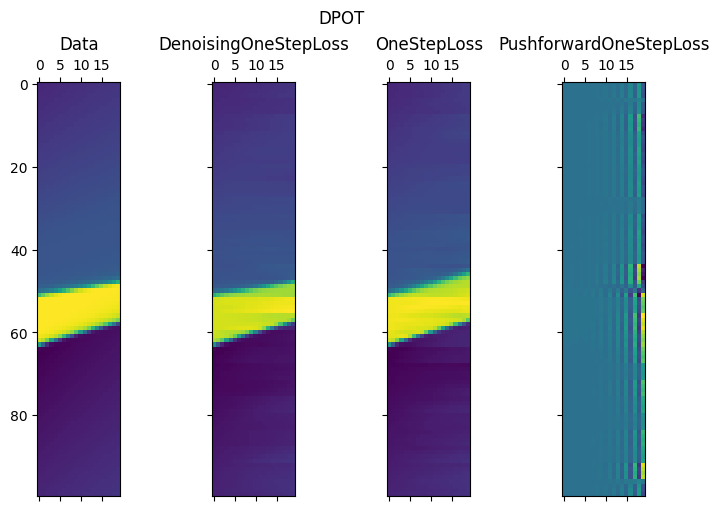

In [35]:
from tqdm import tqdm


u_pred_dict = dict()

for method, ckpt_name in tqdm(CHECKPOINT_DICT["DPOT"].items()):
    model = load_model(checkpoint_dir / "DPOT" / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=None, num_steps=20)
    )(batch_extrap[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle("DPOT")


100%|██████████| 3/3 [00:31<00:00, 10.66s/it]


Text(0.5, 0.98, 'HyperFluxFNO')

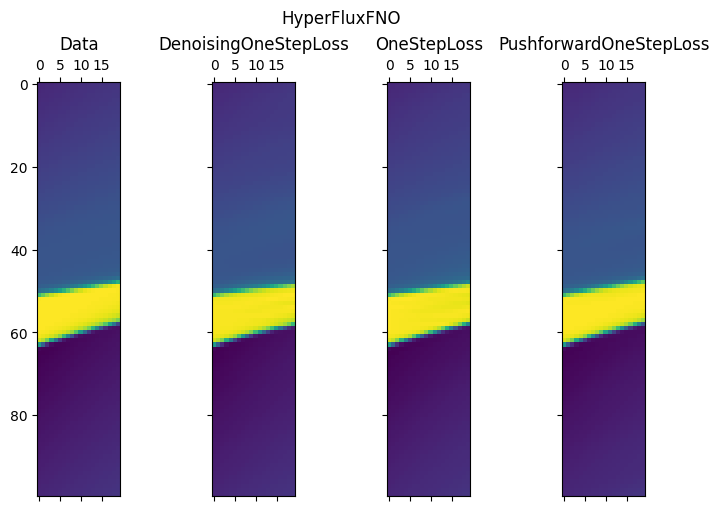

In [14]:
u_pred_dict = dict()

dt = float(dataset_train_extrap["t"][1] - dataset_train_extrap["t"][0])
dx = float(dataset_train_extrap["x"][1] - dataset_train_extrap["x"][0])

model_type = "HyperFluxFNO"
for method, ckpt_name in tqdm(CHECKPOINT_DICT[model_type].items()):
    model = load_model(checkpoint_dir / model_type / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=20)
    )(batch_extrap[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle(model_type)


Text(0.5, 1.0, 'HyperFluxFNO')

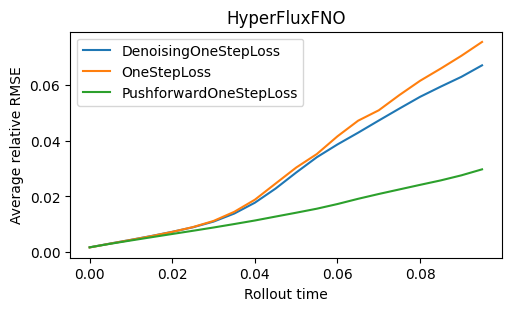

In [19]:
def relative_rmse(
    u_pred: Float[Array, "channels ..."], u_data: Float[Array, "channels ..."]
):
    return jnp.sqrt(jnp.mean((u_pred - u_data) ** 2)) / jnp.sqrt(jnp.mean(u_data**2))


sample_idx = 0
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    rel_rmse = jnp.mean(
        jax.vmap(jax.vmap(relative_rmse))(batch_extrap[:, 20:], u_pred),
        axis=0,
    )
    ax.plot(jnp.arange(len(rel_rmse)) * dt, rel_rmse, label=method)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
ax.set_title(model_type)

100%|██████████| 3/3 [02:09<00:00, 43.16s/it]


Text(0.5, 0.98, 'HyperFluxFNOLocal')

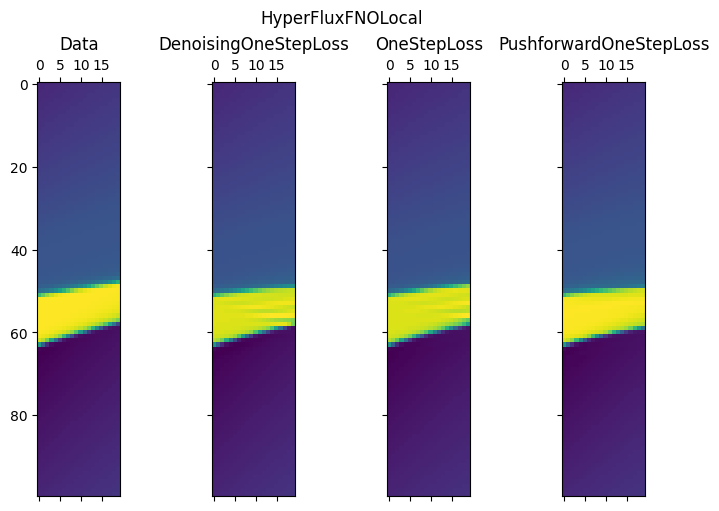

In [20]:
u_pred_dict = dict()

dt = float(dataset_train_extrap["t"][1] - dataset_train_extrap["t"][0])
dx = float(dataset_train_extrap["x"][1] - dataset_train_extrap["x"][0])

model_type = "HyperFluxFNOLocal"
for method, ckpt_name in tqdm(CHECKPOINT_DICT[model_type].items()):
    model = load_model(checkpoint_dir / model_type / method / ckpt_name)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[method] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=20)
    )(batch_extrap[:, :20])[0]

sample_idx = 0
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[0].set_title("Data")
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(method)
fig.suptitle(model_type)


Text(0.5, 1.0, 'HyperFluxFNOLocal')

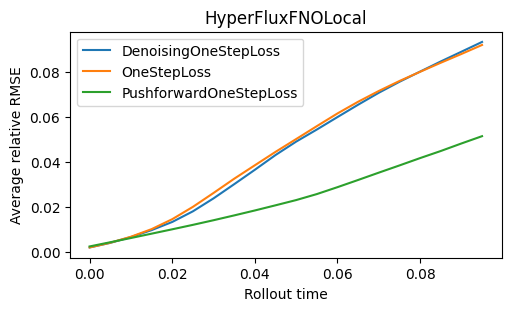

In [22]:
def relative_rmse(
    u_pred: Float[Array, "channels ..."], u_data: Float[Array, "channels ..."]
):
    return jnp.sqrt(jnp.mean((u_pred - u_data) ** 2)) / jnp.sqrt(jnp.mean(u_data**2))


sample_idx = 0
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
for i, (method, u_pred) in enumerate(u_pred_dict.items()):
    rel_rmse = jnp.mean(
        jax.vmap(jax.vmap(relative_rmse))(batch_extrap[:, 20:], u_pred),
        axis=0,
    )
    ax.plot(jnp.arange(len(rel_rmse)) * dt, rel_rmse, label=method)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
ax.set_title(model_type)

## Compare best results

In [25]:
u_pred_dict = dict()

model_method_list = [
    ("DPOT", "DenoisingOneStepLoss"),
    ("HyperFluxFNO", "PushforwardOneStepLoss"),
    ("HyperFluxFNOLocal", "PushforwardOneStepLoss"),
]
for model_type, method in tqdm(model_method_list):
    model = load_model(
        checkpoint_dir / model_type / method / CHECKPOINT_DICT[model_type][method]
    )
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[model_type] = eqx.filter_vmap(
        lambda u: model.rollout(u, args=(dt, dx), num_steps=20)
    )(batch_extrap[:, :20])[0]

  0%|          | 0/3 [00:00<?, ?it/s]ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x1538d301f2c0> is already entered
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-2835' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-2836' coro=<Kernel.shell_main() running at /home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python

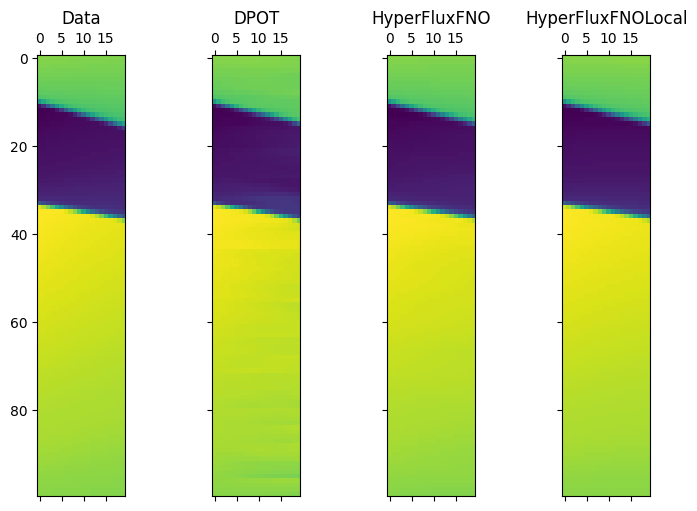

In [30]:
sample_idx = 100
fig, axes = plt.subplots(
    1, 4, figsize=(7, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[0].set_title("Data")
for i, (model_type, u_pred) in enumerate(u_pred_dict.items()):
    axes[i + 1].matshow(u_pred[sample_idx, :, 0].T)
    axes[i + 1].set_title(model_type)


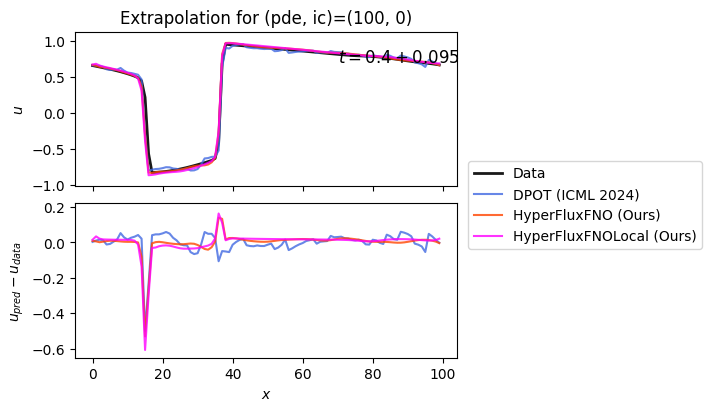

In [31]:
plt.rcParams["animation.html"] = "jshtml"
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True, constrained_layout=True)

COLOR_DICT = {
    "DPOT": "royalblue",
    "HyperFluxFNO": "orangered",
    "HyperFluxFNOLocal": "magenta",
}
LABEL_DICT = {
    "DPOT": "DPOT (ICML 2024)",
    "HyperFluxFNO": "HyperFluxFNO (Ours)",
    "HyperFluxFNOLocal": "HyperFluxFNOLocal (Ours)",
}


def make_frame(timestep: int):
    if timestep == 0:
        plot_kwargs = {"animated": False}
        axes[-1].set_xlabel("$x$")
        axes[0].set_ylabel("$u$")
        axes[1].set_ylabel("$u_{pred}-u_{data}$")
    else:
        plot_kwargs = {"animated": True}

    plot1 = axes[0].plot(
        batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="Data",
        linewidth=2.0,
        color="black",
        alpha=0.9,
        **plot_kwargs,
    )[0]
    plots = []
    for model_type, u_pred in u_pred_dict.items():
        p0 = axes[0].plot(
            u_pred[sample_idx, timestep, 0].T,
            label=LABEL_DICT[model_type],
            alpha=0.8,
            linewidth=1.5,
            color=COLOR_DICT[model_type],
            **plot_kwargs,
        )[0]
        p1 = axes[1].plot(
            u_pred[sample_idx, timestep, 0].T
            - batch_extrap[sample_idx, 20 + timestep, 0].T,
            label=LABEL_DICT[model_type],
            alpha=0.8,
            linewidth=1.5,
            color=COLOR_DICT[model_type],
            **plot_kwargs,
        )[0]
        plots.append(p0)
        plots.append(p1)

    text_y = (
        jnp.max(batch_extrap[sample_idx, :, 0]) * 0.8
        + jnp.min(batch_extrap[sample_idx, :, 0]) * 0.2
    )
    text0 = axes[0].text(70, text_y, f"$t=0.4+{dt * timestep:.3f}$", fontsize="large")
    if timestep == 0:
        fig.legend(*axes[0].get_legend_handles_labels(), loc="outside center right")
    axes[0].set_title(f"Extrapolation for (pde, ic)={(sample_idx, 0)}")
    return (plot1, *plots, text0)


frames = [make_frame(i) for i in range(20)]


ani = ArtistAnimation(fig, frames, interval=50, blit=True)
# ani.save(f"../../figures/cubic_extrapolation_{sample_idx}_0.gif")
ani

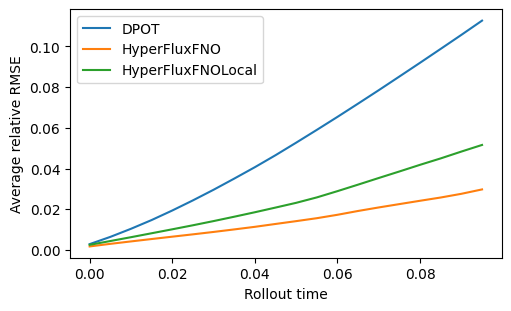

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
for i, (model_type, u_pred) in enumerate(u_pred_dict.items()):
    rel_rmse = jnp.mean(
        jax.vmap(jax.vmap(relative_rmse))(batch_extrap[:, 20:], u_pred),
        axis=0,
    )
    ax.plot(jnp.arange(len(rel_rmse)) * dt, rel_rmse, label=model_type)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
